In [1]:
import pandas as pd
import numpy as np
import sys, os
from pathlib import Path
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import train_test_split

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Add project root to path
project_root = Path.cwd().parent  # parent of notebooks/
sys.path.append(str(project_root))

from src.data_preprocessing import Preprocessing


## init data

In [2]:

def init_data(df: pd.DataFrame):
    new_df = df.copy()

    processing = Preprocessing()
    processing.fit(new_df)
    new_df = processing.transform(new_df)

    X = new_df
    y = df['churn']

    # dataset을 train/test set으로 분리
    return train_test_split(
        X,
        y,
        test_size=0.25,
        stratify=y,
        random_state=42
    )

df = pd.read_csv("../data/bank_customer_churn_prediction.csv")
X_train, X_test, y_train, y_test = init_data(df)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

>>>>> final columns :  Index(['tenure', 'credit_score', 'estimated_salary', 'products_number',
       'balance', 'credit_card', 'active_member', 'gender_Female',
       'gender_Male', 'country_France', 'country_Germany', 'country_Spain',
       'age_group'],
      dtype='object')


((7500, 13), (2500, 13), (7500,), (2500,))

In [3]:
def get_top_n_features(feature_names, importances, n=5):
    # 절대값 변환
    abs_imp = np.abs(importances)
    
    # DataFrame으로 정리
    df_imp = pd.DataFrame({
        "feature": feature_names,
        "importance": abs_imp
    })

    # 중요도 내림차순 정렬
    df_sorted = df_imp.sort_values("importance", ascending=False)

    # 상위 N개 feature 이름 리턴
    return df_sorted.head(n)["feature"].tolist()

## K-Fold init data

In [16]:

def init_data(df: pd.DataFrame):
    new_df = df.copy()

    processing = Preprocessing()
    processing.fit(new_df)
    new_df = processing.transform(new_df)

    X = new_df
    y = df['churn']

    # dataset을 train/test set으로 분리
    return train_test_split(
        X,
        y,
        test_size=0.25,
        stratify=y,
        random_state=42
    )

df = pd.read_csv("../data/bank_customer_churn_prediction.csv")
X_train, X_test, y_train, y_test = init_data(df)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

>>>>> final columns :  Index(['tenure', 'credit_score', 'estimated_salary', 'products_number',
       'balance', 'credit_card', 'active_member', 'gender_Female',
       'gender_Male', 'country_France', 'country_Germany', 'country_Spain',
       'age_group', 'age_x_active', 'products_x_active', 'age_x_products',
       'estimated_x_age', 'estimated_x_active'],
      dtype='object')


((7500, 18), (2500, 18), (7500,), (2500,))

### model 비교

In [11]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000),
    "RandomForest": RandomForestClassifier(
        n_estimators=300, max_depth=8, random_state=42
    ),
    "XGBoost": XGBClassifier(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        random_state=42
    ),
    "LightGBM": LGBMClassifier(
        n_estimators=300,
        max_depth=-1,          # 제한 해제
        num_leaves=31,         # 필요에 따라 더 크게
        min_child_samples=10,  # 기본값보다 낮춰 분할 허용
        min_split_gain=0.0,    # 분할 이득 기준 완화
        learning_rate=0.05,
        random_state=42
    )
}

In [ ]:
results = []
probas = []

for name, model in models.items():
    model.fit(X_train, y_train)

    # 'age_x_active', 'products_x_active', 'age_x_products
    if name == "LogisticRegression":
        # ['active_member', 'gender_Male', 'country_France', 'country_Spain', 'age_group']
        feature_importances = get_top_n_features(X_train.columns, model.coef_[0])
        print(f"{name} FEATURE IMPORTANCES : \n{feature_importances}")
    else:
        # ['age', 'products_number', 'age_group']
        feature_importances = get_top_n_features(X_train.columns, model.feature_importances_)
        print(f"{name} FEATURE IMPORTANCES : \n{feature_importances}")

    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]

    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    f1 = f1_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)

    results.append([name, accuracy, precision, recall, f1, auc])
    probas.append([name, pred, proba])

results

LogisticRegression FEATURE IMPORTANCES : 
['active_member', 'gender_Male', 'country_France', 'country_Spain', 'age_group']
RandomForest FEATURE IMPORTANCES : 
['age', 'products_number', 'age_group', 'balance', 'active_member']
XGBoost FEATURE IMPORTANCES : 
['age_group', 'products_number', 'active_member', 'age', 'country_Germany']
[LightGBM] [Info] Number of positive: 1528, number of negative: 5972
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000338 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 866
[LightGBM] [Info] Number of data points in the train set: 7500, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203733 -> initscore=-1.363122
[LightGBM] [Info] Start training from score -1.363122
LightGBM FEATURE IMPORTANCES : 
['estimated_salary', 'credit_score', 'balance', 'age', 'tenure']


[['LogisticRegression',
  0.8144,
  0.6380368098159509,
  0.2043222003929273,
  0.30952380952380953,
  0.7872281849856771],
 ['RandomForest',
  0.8684,
  0.8383458646616542,
  0.4381139489194499,
  0.5754838709677419,
  0.8713947537987743],
 ['XGBoost',
  0.868,
  0.7640117994100295,
  0.5088408644400786,
  0.6108490566037735,
  0.8710671499152868],
 ['LightGBM',
  0.8656,
  0.7464387464387464,
  0.5147347740667977,
  0.6093023255813953,
  0.8663780726432007]]

In [18]:
# Interaction Feature 이전

columns = ["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
df_results = pd.DataFrame(results, columns=columns)
df_results

# 모두 높을수록 좋다.
# 1. Recall : 이탈 확률이 높은 고객의 정확도. 이탈 확률이 높은 고객을 미리 알고 대응할 수 있기때문에 이탈 문제에서 중요한 평가지표. **
# 2. Precision : churn이라고 예측한 고객 중 진짜 churn인 비율
# 3. F1-score : (Precision + Recall 균형)
# 4. ROC-AUC : 모델 종합 능력 평가

NameError: name 'results' is not defined

### Hyperparameter 적용 버전

In [ ]:
from src.tuner_model import MultiModelTuner

models_with_params = {
    "LogisticRegression": (
        LogisticRegression(max_iter=3000, random_state=42),
        {
            "C": [0.001, 0.01, 0.1, 1, 3, 5, 10],   # 규제 강도
            "penalty": ["l1", "l2", "elasticnet"],
            "solver": ["saga"],
            "l1_ratio": [0, 0.3, 0.5, 0.7, 1]       # elasticnet 전용
        }
    ),

    "RandomForest": (
        RandomForestClassifier(random_state=42),
        {
            "n_estimators": [200, 300, 500],
            "max_depth": [4, 6, 8, 10],
            "min_samples_split": [2, 5, 10],
            "min_samples_leaf": [1, 2, 4],
        }
    ),

    "XGBoost": (
        XGBClassifier(eval_metric="logloss", random_state=42),
        {
            "n_estimators": [200, 300, 500],
            "max_depth": [3, 4, 5, 6],
            "learning_rate": [0.01, 0.05, 0.1],
            "subsample": [0.6, 0.8, 1.0],
            "colsample_bytree": [0.6, 0.8, 1.0],
            "tree_method" : ["approx"]
        }
    ),

    "LightGBM": (
        LGBMClassifier(random_state=42),
        {
            "n_estimators": [200, 300, 500],
            "max_depth": [-1, 4, 6, 8],
            "learning_rate": [0.01, 0.05, 0.1],
            "num_leaves": [15, 31, 63],
        }
    )
}

tuner = MultiModelTuner(models_with_params, n_iter=20)


In [5]:
best_models = tuner.tune(X_train, y_train)

▶ Tuning LogisticRegression ...


/Users/kim/Documents/lucyMacBookPro/SKN/팀프로젝트_2차/SKN21-2nd-1Team/grkim/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
/Users/kim/Documents/lucyMacBookPro/SKN/팀프로젝트_2차/SKN21-2nd-1Team/grkim/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/kim/Documents/lucyMacBookPro/SKN/팀프로젝트_2차/SKN21-2nd-1Team/grkim/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l1)
  warnings.warn(
/Users/kim/Documents/lucyMacBookPro/SKN/팀프로젝트_2차/SKN21-2nd-1Team/grkim/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1221: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l

✔ LogisticRegression tuning completed. Best model found.
  → {'solver': 'saga', 'penalty': 'l1', 'l1_ratio': 0, 'C': 0.1}

▶ Tuning RandomForest ...
✔ RandomForest tuning completed. Best model found.
  → {'n_estimators': 300, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 10}

▶ Tuning XGBoost ...
✔ XGBoost tuning completed. Best model found.
  → {'tree_method': 'approx', 'subsample': 0.8, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6}

▶ Tuning LightGBM ...
[LightGBM] [Info] Number of positive: 1018, number of negative: 3982
[LightGBM] [Info] Number of positive: 1018, number of negative: 3982
[LightGBM] [Info] Number of positive: 1018, number of negative: 3982
[LightGBM] [Info] Number of positive: 1019, number of negative: 3981
[LightGBM] [Info] Number of positive: 1019, number of negative: 3981
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001172 seconds.
You can set `force_col_wise=true` to

In [6]:
X_train.columns, best_models

(Index(['tenure', 'credit_score', 'estimated_salary', 'products_number',
        'balance', 'credit_card', 'active_member', 'gender_Female',
        'gender_Male', 'country_France', 'country_Germany', 'country_Spain',
        'age_group'],
       dtype='object'),
 {'LogisticRegression': LogisticRegression(C=0.1, l1_ratio=0, max_iter=3000, penalty='l1',
                     random_state=42, solver='saga'),
  'RandomForest': RandomForestClassifier(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                         n_estimators=300, random_state=42),
  'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
                colsample_bylevel=None, colsample_bynode=None,
                colsample_bytree=0.6, device=None, early_stopping_rounds=None,
                enable_categorical=False, eval_metric='logloss',
                feature_types=None, feature_weights=None, gamma=None,
                grow_policy=None, importance_type=None,
                interactio

In [7]:
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

df_results = []
pred_proba_list = []

for name, model in best_models.items():
    if name == "LogisticRegression":
        feature_importances = get_top_n_features(X_train.columns, model.coef_[0])
        print(f"{name} FEATURE IMPORTANCES : \n{feature_importances}")
    else:
        feature_importances = get_top_n_features(X_train.columns, model.feature_importances_)
        print(f"{name} FEATURE IMPORTANCES : \n{feature_importances}")


    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    
    # 임계값 설정
    thresh = 0.2
    proba_thresh =  np.where(proba >= thresh, 1, 0)
    print(proba_thresh)
    pred_proba_list.append({name:[pred, proba]})

    confusion = confusion_matrix(y_test, proba_thresh)

    accuracy = accuracy_score(y_test, proba_thresh)
    precision = precision_score(y_test, proba_thresh)
    recall = recall_score(y_test, proba_thresh)
    f1 = f1_score(y_test, pred)
    auc = roc_auc_score(y_test, proba)

    print(confusion)
    
    print('정확도 : {0:.4f}, 정밀도 : {1:.4f}, 재현율 : {2:.4f}, f1 : {3:0.4f}, auc : {4:0.4f}'.format(accuracy, precision, recall, f1, auc))

    df_results.append({name:[accuracy, precision, recall, f1, auc]})

LogisticRegression FEATURE IMPORTANCES : 
['active_member', 'country_Germany', 'age_group', 'gender_Male', 'balance']
[1 0 1 ... 1 1 1]
[[1396  595]
 [ 133  376]]
정확도 : 0.7088, 정밀도 : 0.3872, 재현율 : 0.7387, f1 : 0.3008, auc : 0.7876
RandomForest FEATURE IMPORTANCES : 
['age_group', 'products_number', 'balance', 'credit_score', 'estimated_salary']
[0 0 0 ... 1 0 0]
[[1536  455]
 [ 106  403]]
정확도 : 0.7756, 정밀도 : 0.4697, 재현율 : 0.7917, f1 : 0.5617, auc : 0.8689
XGBoost FEATURE IMPORTANCES : 
['products_number', 'age_group', 'active_member', 'country_Germany', 'balance']
[0 0 0 ... 1 0 0]
[[1560  431]
 [ 101  408]]
정확도 : 0.7872, 정밀도 : 0.4863, 재현율 : 0.8016, f1 : 0.5854, auc : 0.8742
LightGBM FEATURE IMPORTANCES : 
['balance', 'products_number', 'age_group', 'estimated_salary', 'credit_score']
[0 0 0 ... 1 0 0]
[[1586  405]
 [ 106  403]]
정확도 : 0.7956, 정밀도 : 0.4988, 재현율 : 0.7917, f1 : 0.5873, auc : 0.8751


             recall  precision
threshold                     
0          1.000000   0.203600
1          0.184676   0.783333
1          0.000000   1.000000


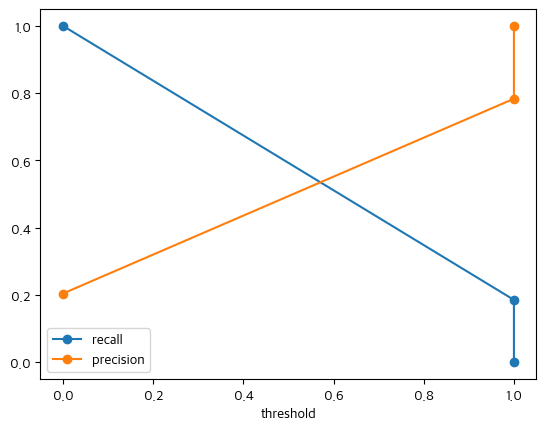

AttributeError: 'DataFrame' object has no attribute 'reshape'

In [17]:
import matplotlib.pyplot as plt

for index, prc_df in enumerate(prc_df_list):
    name = df_results[index]
    print(prc_df)
    prc_df.plot(marker='o')
    plt.show()


    confusion = confusion_matrix(y_test, pred)
    accuracy = accuracy_score(y_test, pred)
    precision = precision_score(y_test, pred)
    recall = recall_score(y_test, pred)
    print('오차 행렬')
    print(confusion)
    print('정확도 : {0:.4f}, 정밀도 : {1:.4f}, 재현율 : {2:.4f}'.format(accuracy, precision, recall))



In [20]:
# Interaction Feature 이후 버전
import pandas as pd

columns = ["Model", "Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]
df_results = pd.DataFrame(df_results, columns=columns)
df_results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,LogisticRegression,0.8332,0.744681,0.275049,0.401722,0.793038
1,RandomForest,0.8716,0.833333,0.461690,0.594185,0.873945
2,XGBoost,0.8740,0.825503,0.483301,0.609665,0.877965
3,LightGBM,0.8716,0.817568,0.475442,0.601242,0.877809


# Pipeline 적용 ==========================================

In [41]:
import pandas as pd
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV

import sys
from pathlib import Path
# Add project root to path
project_root = Path.cwd().parent  # parent of notebooks/
sys.path.append(str(project_root))

from src.data_preprocessing import PipelinePreprocessing

df = pd.read_csv("../data/bank_customer_churn_prediction.csv")

X = df.drop(columns=["churn"])
y = df["churn"]

    # dataset을 train/test set으로 분리
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.25,
                                                    stratify=y,
                                                    random_state=42)



for i in models_with_params:
    print(i)

pre_pipeline = PipelinePreprocessing().create_pipeline(X_train)
result = pre_pipeline.fit_transform(X_train, y_train)

best_models = {}

for name, (model, params) in models_with_params.items():

    search = GridSearchCV(
        estimator=model,
        param_grid=params,
        scoring="roc_auc",
        cv=3,
        n_jobs=-1
    )

    # search.fit(result, y_train)
    best_models[name] = search.best_estimator_
    print(">>>>>>>>>>. best_estimator_ : ", search.best_estimator_)




LogisticRegression
RandomForest
XGBoost
LightGBM
[Pipeline]  (step 1 of 2) Processing interaction_preprocessor, total=   0.0s
[Pipeline] ....... (step 2 of 2) Processing transformer, total=   0.0s


/Users/kim/.local/share/uv/python/cpython-3.13.9-macos-aarch64-none/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/kim/.local/share/uv/python/cpython-3.13.9-macos-aarch64-none/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/Users/kim/.local/share/uv/python/cpython-3.13.9-macos-aarch64-none/lib/python3.13/multiprocessing/queues.py:120: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resou

>>>>>>>>>>. best_estimator_ :  LogisticRegression(C=0.001, l1_ratio=0.3, max_iter=3000, penalty='elasticnet',
                   random_state=42, solver='saga')
>>>>>>>>>>. best_estimator_ :  RandomForestClassifier(max_depth=10, min_samples_leaf=4, min_samples_split=10,
                       n_estimators=500, random_state=42)
>>>>>>>>>>. best_estimator_ :  XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.01, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, m

/Users/kim/Documents/lucyMacBookPro/SKN/팀프로젝트_2차/SKN21-2nd-1Team/grkim/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kim/Documents/lucyMacBookPro/SKN/팀프로젝트_2차/SKN21-2nd-1Team/grkim/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kim/Documents/lucyMacBookPro/SKN/팀프로젝트_2차/SKN21-2nd-1Team/grkim/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/Users/kim/Documents/lucyMacBookPro/SKN/팀프로젝트_2차/SKN21-2nd-1Team/grkim/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature

[LightGBM] [Info] Number of positive: 1019, number of negative: 3981
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000930 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1569
[LightGBM] [Info] Number of data points in the train set: 5000, number of used features: 19
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203800 -> initscore=-1.362711
[LightGBM] [Info] Start training from score -1.362711
[LightGBM] [Info] Number of positive: 1019, number of negative: 3981
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000794 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1566
[LightGBM] [Info] Number of positive: 1019, number of negative: 3981
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000912 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [I

...

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 1018, number of negative: 3982
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001180 seconds.
You can set `force_col_wise=true` to remove the overhead.[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

[LightGBM] [Info] T

/Users/kim/Documents/lucyMacBookPro/SKN/팀프로젝트_2차/SKN21-2nd-1Team/grkim/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 1019, number of negative: 3981
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001016 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] T

Exception ignored on calling ctypes callback function <function _log_callback at 0x11d4709a0>:
Traceback (most recent call last):
  File "/Users/kim/Documents/lucyMacBookPro/SKN/팀프로젝트_2차/SKN21-2nd-1Team/grkim/.venv/lib/python3.13/site-packages/lightgbm/basic.py", line 287, in _log_callback
    def _log_callback(msg: bytes) -> None:
KeyboardInterrupt: 
Exception ignored on calling ctypes callback function <function _log_callback at 0x11c134b80>:
Traceback (most recent call last):
  File "/Users/kim/Documents/lucyMacBookPro/SKN/팀프로젝트_2차/SKN21-2nd-1Team/grkim/.venv/lib/python3.13/site-packages/lightgbm/basic.py", line 287, in _log_callback
    def _log_callback(msg: bytes) -> None:
KeyboardInterrupt: 
Exception ignored on calling ctypes callback function <function _log_callback at 0x11f518b80>:
Traceback (most recent call last):
  File "/Users/kim/Documents/lucyMacBookPro/SKN/팀프로젝트_2차/SKN21-2nd-1Team/grkim/.venv/lib/python3.13/site-packages/lightgbm/basic.py", line 287, in _log_callback
 

KeyboardInterrupt: 